In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- STEP 1: LOAD THE DATA ---

file_path = 'sales_data.csv'
df = pd.read_csv(file_path)


In [2]:
# --- STEP 2: DATA EXPLORATION ---
print("\n--- DATA PREVIEW (First 5 Rows) ---")
print(df.head())

# --- STEP 3: DATA CLEANING ---
# Removing duplicates and handling missing values (Handling null objects)
df_cleaned = df.drop_duplicates()
df_cleaned = df_cleaned.dropna()


--- DATA PREVIEW (First 5 Rows) ---
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680


In [3]:
# --- STEP 4: SALES ANALYSIS (Calculating Metrics) ---

# Metric 1: Total Revenue (Summation of the Total_Sales column)
total_revenue = df_cleaned['Total_Sales'].sum()

# Metric 2: Best-Selling Product by Revenue (Grouping Object)
product_performance = df_cleaned.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
best_product = product_performance.idxmax()

# Metric 3: Average Order Value
avg_order = df_cleaned['Total_Sales'].mean()


In [4]:
# Metric 4: Regional Performance
regional_performance = df_cleaned.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False)

# --- STEP 5: GENERATE THE REPORT ---
print("\n" + "="*45)
print("        WEEK 4 SALES ANALYSIS REPORT")
print("="*45)
print(f"Total Revenue Achieved:   ₹{total_revenue:,.2f}")
print(f"Average Sale Value:       ₹{avg_order:,.2f}")
print(f"Top Performing Product:   {best_product}")
print(f"Leading Sales Region:     {regional_performance.idxmax()}")
print("-" * 45)
print("\nRevenue by Product:")
print(product_performance.to_string())
print("\nRevenue by Region:")
print(regional_performance.to_string())
print("="*45)




        WEEK 4 SALES ANALYSIS REPORT
Total Revenue Achieved:   ₹12,365,048.00
Average Sale Value:       ₹123,650.48
Top Performing Product:   Laptop
Leading Sales Region:     North
---------------------------------------------

Revenue by Product:
Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071

Revenue by Region:
Region
North    3983635
South    3737852
East     2519639
West     2123922


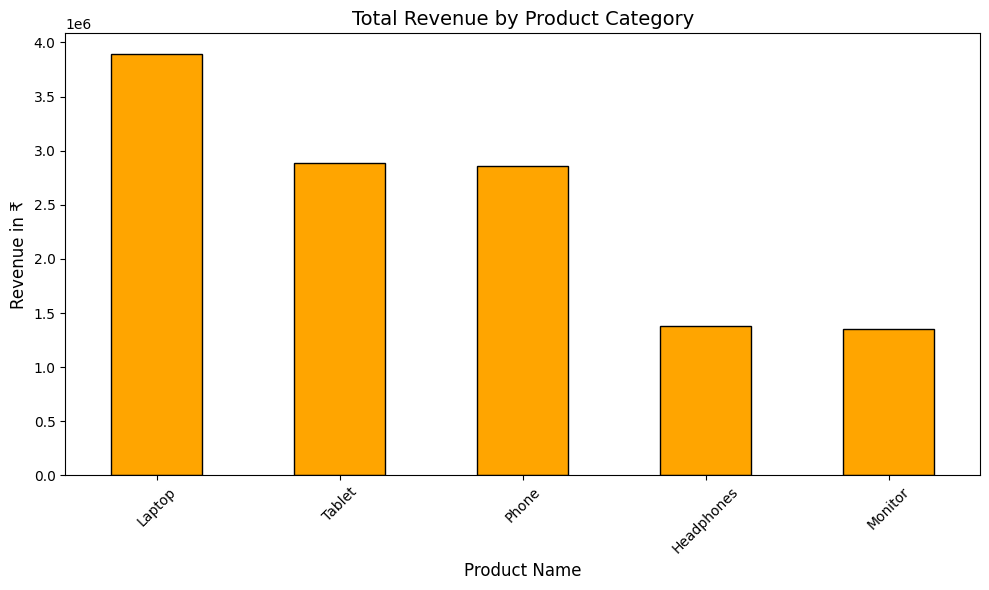

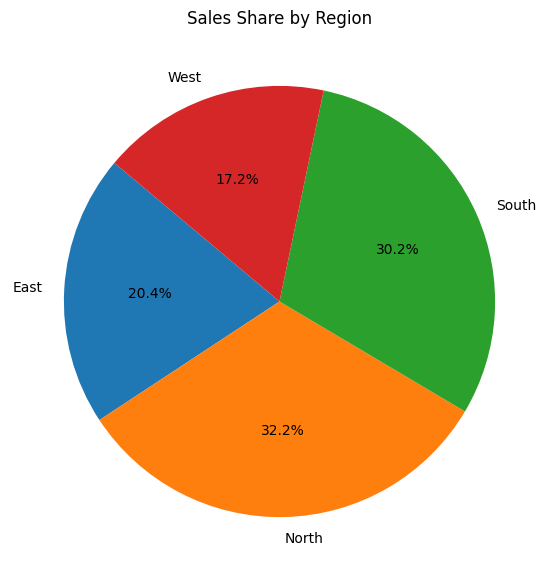

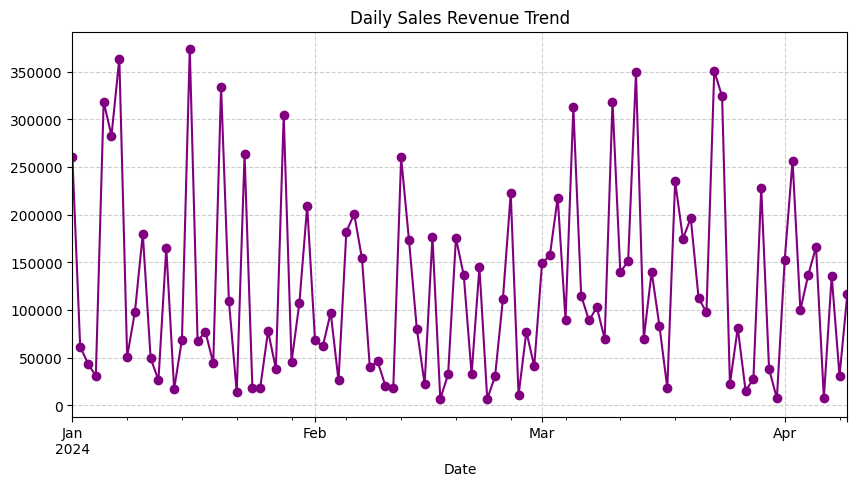

In [5]:
# --- STEP 6: DATA VISUALIZATION ----
plt.figure(figsize=(10, 6))
product_performance.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Total Revenue by Product Category', fontsize=14)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Revenue in ₹', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# --- PIE CHART: Regional Sales ---
plt.figure(figsize=(7, 7))
df_cleaned.groupby('Region')['Total_Sales'].sum().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Sales Share by Region')
plt.ylabel('') # Hides the 'Total_Sales' label on the side

# --- LINE CHART: Sales Trend ---
# Convert date to make sure it is in order
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
daily_sales = df_cleaned.groupby('Date')['Total_Sales'].sum()

plt.figure(figsize=(10, 5))
daily_sales.plot(kind='line', marker='o', color='purple')
plt.title('Daily Sales Revenue Trend')
plt.grid(True, linestyle='--', alpha=0.6)